# **Load Dataset**

In [2]:
import torch
import torch.nn as nn
import torchvision
from torchvision.transforms import transforms
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
from sklearn.metrics import accuracy_score

In [3]:
dataset = torchvision.datasets.CIFAR10('/content/', train=True, download=True, transform=transforms.ToTensor())
classes = {'plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'}
trainloader = torch.utils.data.DataLoader(dataset, batch_size=4, shuffle=True)


100%|██████████| 170M/170M [00:03<00:00, 43.2MB/s]


tensor([9, 3, 5, 4])


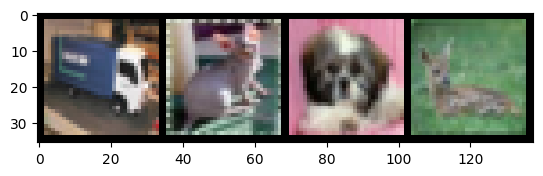

In [4]:
dataiter = iter(trainloader)
images, labels = next(dataiter)
def image_viz(img):
    image = img.numpy()
    image = np.transpose(image, (1, 2, 0))
    imshow(image)
fullgrid = torchvision.utils.make_grid(images)
image_viz(fullgrid)
print(labels)

In [14]:
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        self.cnnmodel = nn.Sequential(
            nn.Conv2d(3, 10, 5), # Convolution layer
            nn.LeakyReLU(),          # Activation function
            nn.MaxPool2d(2, 2), # Pooling layer
            nn.Conv2d(10, 32, 5),
            nn.ReLU(),
            nn.AvgPool2d(2, 2)
        )
        self.fullyconn = nn.Sequential(
            nn.Linear(800, 120), # Linear Layer
            nn.ReLU(),           # ReLU Activation Function
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, 10)
        )

    def forward(self, x):
        x = self.cnnmodel(x)
        x = x.view(x.size(0), -1)
        x = self.fullyconn(x)
        return x

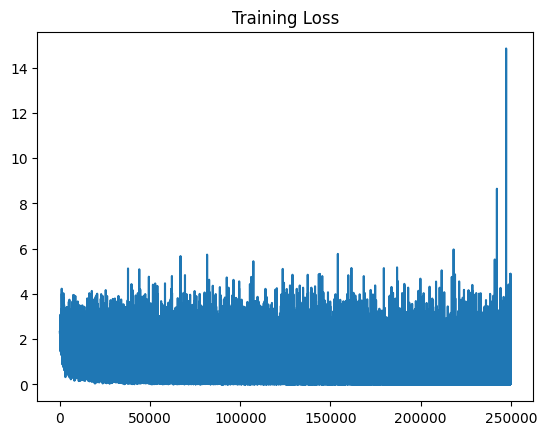

In [15]:
mymodel = LeNet().to('cuda:0') # Move the model to GPU if available
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mymodel.parameters(), lr=0.001)

loss_arr = []
for epoch in range(20):
    for single_batch in trainloader:
        images, labels = single_batch
        images, labels = images.to('cuda:0'), labels.to('cuda:0')
        ypred = mymodel.forward(images)
        loss = loss_fn(ypred, labels)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loss_arr.append(loss.item())
plt.plot(loss_arr)
plt.title('Training Loss')
plt.show()

In [16]:
def evaluation(data, model):
    total, correct = 0, 0
    for images, labels in data:
        images = images.to('cuda:0')
        ypred = model.forward(images)
        _, predicted = torch.max(ypred.data, 1)
        total += labels.size(0)
        correct += (predicted == labels.to('cuda:0')).sum().item()
    return 100 * correct / total

# Define test dataset and testloader
test_dataset = torchvision.datasets.CIFAR10('/content/', train=False, download=True, transform=transforms.ToTensor())
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=4, shuffle=False)

train_accuracy = evaluation(trainloader, mymodel)
test_accuracy = evaluation(testloader, mymodel)

print(f'Train Accuracy: {train_accuracy}%')
print(f'Test Accuracy: {test_accuracy}%')

Train Accuracy: 77.228%
Test Accuracy: 61.6%
